In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/insurance.csv")

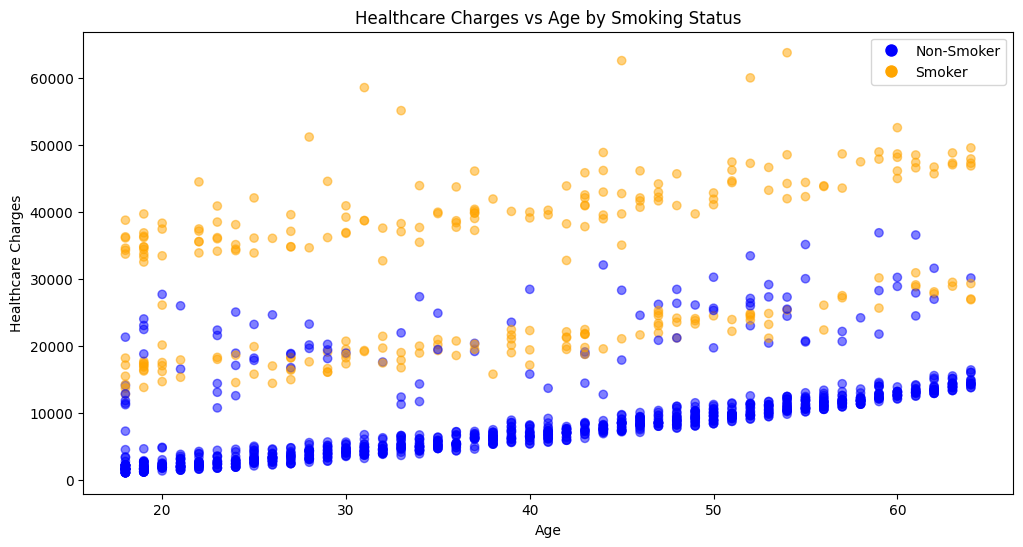

In [6]:
plt.figure(figsize=(12,6))

colors = df["smoker"].map({
    "no": "blue",
    "yes": "orange"
})

plt.scatter(
    df["age"],
    df["charges"],
    c=colors,
    alpha=0.5
)

plt.title("Healthcare Charges vs Age by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Healthcare Charges")

plt.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='blue', label='Non-Smoker', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='orange', label='Smoker', markersize=10)
    ]
)

plt.savefig(
    "../visuals/charges_vs_age_smoking.png",
    bbox_inches="tight"
)

plt.show()

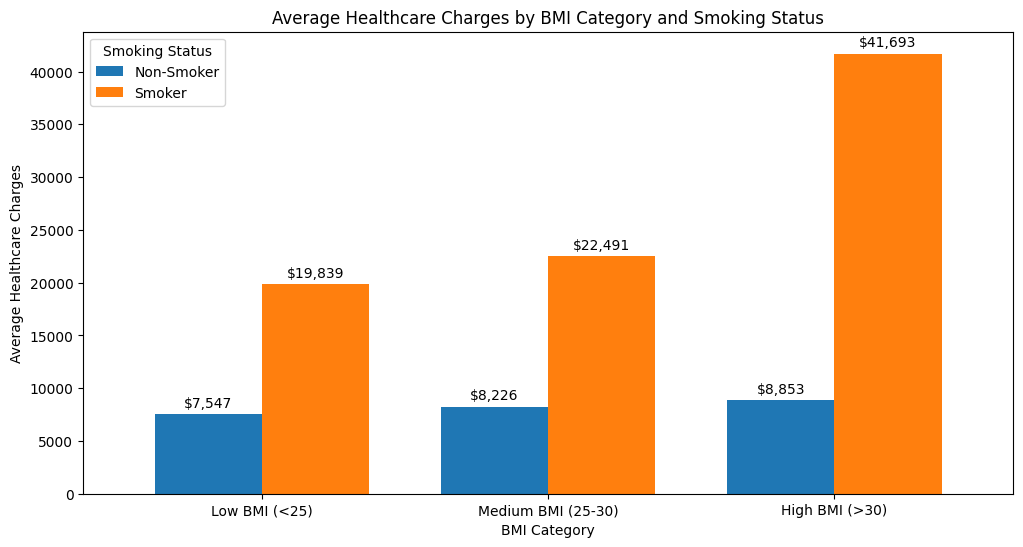

In [7]:
import matplotlib.pyplot as plt
import numpy as np


df["bmi_group"] = pd.cut(
    df["bmi"],
    bins=[0, 25, 30, 100],
    labels=["Low BMI (<25)", "Medium BMI (25-30)", "High BMI (>30)"]
)

bmi_smoker_avg = df.groupby(["bmi_group", "smoker"])["charges"].mean().unstack()


bmi_smoker_avg = bmi_smoker_avg[["no", "yes"]]


ax = bmi_smoker_avg.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.75
)

plt.title("Average Healthcare Charges by BMI Category and Smoking Status")
plt.xlabel("BMI Category")
plt.ylabel("Average Healthcare Charges")
plt.xticks(rotation=0)

plt.legend(["Non-Smoker", "Smoker"], title="Smoking Status")

# Add dollar labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"${v:,.0f}" for v in container.datavalues],
        padding=3
    )

plt.savefig(
    "../visuals/charges_by_bmi_and_smoking_status.png",
    bbox_inches="tight"
)

plt.show()